In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.tree import DecisionTreeRegressor
from sklearn import tree
from sklearn.model_selection import cross_val_score, KFold
from pathlib import Path
from scipy.interpolate import interp1d

plt.rcParams.update({
    "font.family": "serif",
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "legend.title_fontsize": 12,
    "legend.fontsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "lines.linewidth": 2,
    "lines.markersize": 6,
    "legend.frameon": False,
    "figure.figsize": (9, 3)  # standard size for subplots
})
COLORS = ['#5F6F52', '#A9B388', '#B99470']
COLORS2 = ['#395144', '#4E6C50', '#AA8B56']

# Beef: Data Cleaning, Merging, Preprocessing

In [147]:
beef1 = pd.read_excel('data/raw/raw_beef_data_2farms.xlsx', sheet_name=1)
beef2 = pd.read_excel('data/raw/raw_beef_data_3rdfarm.xlsx')

# focus on important columns before preprocessing
beef1 = beef1[['Date processed (kill date)', 'kill year', 'kill month', 'NZDI',
       'Animals category', ' transport distance (in kms, direct traject)', 
       'Processing location', 'Lairage Time (in hours)', 'Presentation Grade', 
       'Grade', 'live weight', 'carcass weight ', 'Teeth', 'Total number of defects']]
beef2 = beef2[['Date processed (kill date)', 'Type', 'Grade S1',
       'Teeth', 'carcass weight', 'Live Wt.', 'Yield', 'sum defects', 
       'lairage time (calculated)', 'Processing location', 
       'Transport distance (calculated)', 'presentation  Grade', 'NZDI']]

In [148]:
# fill in missing dates
dates = pd.to_datetime(beef2["Date processed (kill date)"], dayfirst=True, errors="coerce").ffill()
beef2["Date processed (kill date)"] = dates

# extract kill year and month
beef2["kill year"]  = beef2["Date processed (kill date)"].dt.year
beef2["kill month"] = beef2["Date processed (kill date)"].dt.month
beef1["kill month"] = beef1["Date processed (kill date)"].dt.month

# rename mismatching columns
beef1 = beef1.rename(columns={"Killsheet # ": "kill sheet#",
                              "Animals category": "Animal Type",
                              " transport distance (in kms, direct traject)": "Transport distance (calculated)",
                              "Lairage Time (in hours)": "lairage time (calculated)",
                              "carcass weight ": "carcass weight",
                              "Date processed (kill date)": "kill date"})
beef2 = beef2.rename(columns={"Type": "Animal Type",
                              "presentation  Grade": "Presentation Grade",
                              "Grade S1": "Grade",
                              "Live Wt.": "live weight",
                              "sum defects": "Total number of defects",
                              "Date processed (kill date)": "kill date"})

# reformat mismatching columns
beef2["Animal Type"] = beef2["Animal Type"].str.lower()
beef1["Processing location"] = beef1["Processing location"].replace({
    "C ": "C",
    "unknown": np.nan
})
beef1["Teeth"] = beef1["Teeth"].replace({"Milk Teeth": 0}).astype("float")

In [149]:
# concatenate both beef datasets
beef = pd.concat([beef1, beef2], ignore_index=True)

In [150]:
# Categorical columns to numeric (scikit-learn models need that)
beef['Animal Type_num'] = pd.Categorical(beef['Animal Type']).codes
beef['Grade_num'] = pd.Categorical(beef['Grade']).codes
beef['Presentation Grade_num'] = pd.Categorical(beef['Presentation Grade']).codes

## Missing Value Imputation

#### NZDI: impute manually from https://shiny.niwa.co.nz/DroughtMonitor/

In [151]:
# manually read NZDI values from Drought Monitor
manual_reads = {
    pd.to_datetime('30/10/2023', dayfirst=True): 95/286,
    pd.to_datetime('23/11/2023', dayfirst=True): 102/286,
    pd.to_datetime('21/05/2024', dayfirst=True): 204/286,
    pd.to_datetime('09/12/2024', dayfirst=True): 130/286
}

# impute into the 4 missing dates
beef["NZDI"] = beef["kill date"].map(manual_reads).combine_first(beef.get("NZDI"))

#### Teeth: impute with decision tree

In [152]:
# create a testing set for which all information is available
test_beef = beef[['live weight', 'kill year', 'kill month', 'Animal Type_num', 'Teeth']].dropna().copy()
X = test_beef.drop(columns=["Teeth"])
y = test_beef["Teeth"]

# test parameter choices 
cv = KFold(n_splits=5, shuffle=True, random_state=42)
for leaf in [1, 2, 5, 10, 20, 50]:
    model = DecisionTreeRegressor(min_samples_leaf=leaf, random_state=42)
    scores = cross_val_score(model, X, y, cv=cv, scoring="neg_mean_squared_error")
    print(f"min_samples_leaf={leaf} -> Mean MSE: {(-scores).mean():.3f}")

# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Decision Tree on all data with fixed parameter value
model = DecisionTreeRegressor(min_samples_leaf=10, random_state=42)
model.fit(X, y)

# impute Teeth
na_teeth = beef['Teeth'].isnull()
predicted_teeth = model.predict(beef.loc[na_teeth, ['live weight', 'kill year', 'kill month', 'Animal Type_num']])
beef.loc[na_teeth, 'Teeth'] = predicted_teeth

min_samples_leaf=1 -> Mean MSE: 1.001
min_samples_leaf=2 -> Mean MSE: 0.863
min_samples_leaf=5 -> Mean MSE: 0.642
min_samples_leaf=10 -> Mean MSE: 0.600
min_samples_leaf=20 -> Mean MSE: 0.637
min_samples_leaf=50 -> Mean MSE: 2.209


#### Transport Distance: via Processing location

In [162]:
matrix = beef.pivot_table(
    index="Transport distance (calculated)",
    columns="Processing location",
    values="kill date",
    aggfunc="count",
    fill_value=0
)
matrix

Processing location,A,B,C
Transport distance (calculated),,,
154.0,81,0,0
164.0,85,0,0
172.0,110,0,0
175.0,0,0,283
185.0,0,0,1
214.0,0,0,15
584.0,0,17,0


In [163]:
# impute the mean distance to the same processing location
means = matrix.mean(axis=0).to_dict()

beef["Transport distance (calculated)"] = beef.apply(
    lambda row: means.get(row["Processing location"], np.nan)
    if pd.isna(row["Transport distance (calculated)"]) else row["Transport distance (calculated)"],
    axis=1
)

## Additional Features

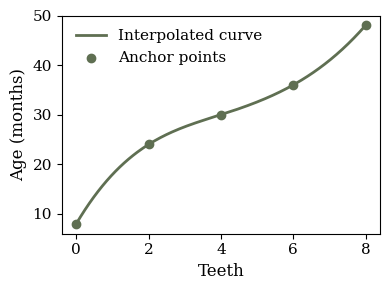

In [165]:
# Age (impute via Teeth)
mapping = {0: 8, 2: 24, 4: 30, 6: 36, 8: 48}
xk = np.array(list(mapping.keys()))
yk = np.array(list(mapping.values()))

# cubic interpolation
f = interp1d(xk, yk, kind="cubic", fill_value="extrapolate")

# impute Age(months)
beef["Age"] = beef["Teeth"].map(mapping)
m = beef["Age"].isna() & beef["Teeth"].notna()
beef.loc[m, "Age"] = f(beef.loc[m, "Teeth"].to_numpy())

# plot curve + true points
xx = np.linspace(0, 8, 200)
plt.figure(figsize=(4,3))
plt.plot(xx, f(xx), label="Interpolated curve", c=COLORS[0])
plt.scatter(xk, yk, zorder=3, label="Anchor points", c=COLORS[0])
plt.xlabel("Teeth")
plt.ylabel("Age (months)")
plt.legend()
plt.tight_layout()
plt.show()

In [166]:
# Waste
beef['Waste'] = beef['live weight'] - beef['carcass weight']

In [167]:
# Price
price_map = {
    ('cow', 'P2'): 3.6,
    ('cow', 'P3'): 3.2,
    ('cow', 'M'): 3.3,
    ('heifer', 'P2'): 5.6,
    ('heifer', 'T2'): 4.9,
    ('heifer', 'P3'): 5.8,
    ('steer', 'P2'): 5.9,
    ('steer', 'L1'): 6.0,
    ('steer', 'T2'): 5.4
}

beef['price/kg'] = beef.apply(lambda row: price_map.get((row['Animal Type'], row['Grade'])), axis=1)
beef['price'] = beef['carcass weight'] * beef['price/kg']

In [168]:
beef.to_csv("data/beef_preprocessed.csv", index=False)

# Weather: Data Cleaning and Preprocessing

In [2]:
# read and concatenate weather files
folder = Path("data/weather/")
files = sorted(folder.glob("*.xlsx"))

dfs = []
for f in files:
    df = pd.read_excel(
        f,
        header=8,          # row 9 has column names (0-indexed)
        usecols="A:U"      # only read columns up to U
    )
    df = df.rename(columns={"HLI2": "Grazing HLI2"})
    dfs.append(df)

# concatenate all into one DataFrame
weather_data = pd.concat(dfs, ignore_index=True)

In [3]:
# clean time stamps
weather_data['Date(NZST)'] = pd.to_datetime(weather_data['Date(NZST)'], format='%Y%m%d')
weather_data["Time(NZST)"] = weather_data["Time(NZST)"].astype(str).str.zfill(4)
s = pd.to_numeric(weather_data["Time(NZST)"], errors="coerce")
z = s.dropna().astype(int).astype(str).str.zfill(4)
weather_data.loc[s.notna(), "Time(NZST)"] = pd.to_datetime(z, format="%H%M").dt.time

# replace "-" with nan
weather_data = weather_data.where(weather_data.ne("-"), np.nan).convert_dtypes()

# remove columns we will not look at
weather_data = weather_data.drop(['GstDir(degT)', 'GstSpd(mps)', 'RadDif(MJ/m2)', 'RadDir(MJ/m2)', 'Pmsl(hPa)', 'StdDir(degT)', 'StdSpd(mps)'], axis=1)

#### Add missing time frames via open-meteo.com

In [4]:
openmeteo = pd.read_csv("data/palmerston_north_openmeteo_20230805_20241209_hourly_pseudo10min_rad.csv")
openmeteo['Date(NZST)'] = pd.to_datetime(openmeteo['Date(NZST)'], format='%d/%m/%Y')
weather_data = pd.concat([weather_data, openmeteo], ignore_index=True)

#### Imputation: Equations for 'Predicted BGT', 'THI', 'HLI', 'Grazing HLI2'; linear interpolation for the rest

In [5]:
# make dtypes numeric where possible before interpolation
weather_data = weather_data.infer_objects(copy=False)

# Linear interpolation on non-target numeric cols only (avoids FutureWarning)
exclude = ['Predicted BGT', 'THI', 'HLI', 'Grazing HLI2']
num_cols = weather_data.drop(columns=exclude).select_dtypes(include=[np.number]).columns
weather_data[num_cols] = weather_data[num_cols].interpolate(method="linear")

# Predicted BGT (compute within masks to avoid sqrt on negatives)
mask_pos = weather_data['MnTemp(C)'] > 0
t_pos = weather_data.loc[mask_pos, 'MnTemp(C)']
sr_pos = weather_data.loc[mask_pos, 'Average W/m2']
weather_data.loc[mask_pos, 'Predicted BGT'] = weather_data.loc[mask_pos, 'Predicted BGT'].fillna(
    1.33 * t_pos - 2.65 * np.sqrt(t_pos) + 3.21 * np.log10(sr_pos + 1) + 3.5
)

mask_neg = ~mask_pos
t_neg = weather_data.loc[mask_neg, 'MnTemp(C)']
sr_neg = weather_data.loc[mask_neg, 'Average W/m2']
weather_data.loc[mask_neg, 'Predicted BGT'] = weather_data.loc[mask_neg, 'Predicted BGT'].fillna(
    1.33 * t_neg + 2.65 * np.sqrt(np.abs(t_neg)) + 3.21 * np.log10(sr_neg + 1) + 3.5
)

# THI
temp = weather_data['MnTemp(C)']
rh = weather_data['MnRH(%)'] * 0.01
weather_data['THI'] = weather_data['THI'].fillna(0.8 * temp + rh * (temp - 14.4) + 46.4)

# HLI
ws = weather_data['MnSpd(mps)']
bgt = weather_data['Predicted BGT']
mask_hli = bgt >= 25
weather_data.loc[mask_hli, 'HLI'] = (
    8.62 + 0.38 * rh.loc[mask_hli] + 1.55 * bgt.loc[mask_hli] + np.exp(-ws.loc[mask_hli] + 2.4) - 0.5 * ws.loc[mask_hli]
)
weather_data.loc[~mask_hli, 'HLI'] = (
    10.66 + 0.208 * rh.loc[~mask_hli] + 1.3 * rh.loc[~mask_hli] - ws.loc[~mask_hli]
)

# Grazing HLI2
rad = weather_data['RadGlb(MJ/m2)']
weather_data['Grazing HLI2'] = weather_data['Grazing HLI2'].fillna(
    61.78 + 4.21 * (temp - 22.48) - 1.7 * (ws - 7.05) + 5.89 * (rad - 2.41)
)

In [8]:
weather_data.to_csv("data/weather_preprocessed.csv", index=False)

# Generate Lag Table

In [ ]:
weather_cols = [
    'MnDir(degT)', 'MnSpd(mps)', 'MnTemp(C)', 'MnRH(%)',
    'Rain(mm)', 'RadGlb(MJ/m2)', 'Average W/m2', 'Predicted BGT', 'THI', 'HLI', 'Grazing HLI2'
]
lags = [2, 3, 7, 14, 21, 30, 60, 90, 180, 360, 720]
aggs = {
    'max': np.nanmax,
    'min': np.nanmin,
    'diff': lambda a: (np.nanmax(a) - np.nanmin(a)),
    'mean': np.nanmean,
    'std': np.nanstd
}

lag_features = {
    d: [f"{col}__lag{d}_{a}" for col in weather_cols for a in aggs]
    for d in lags
}

In [171]:
# ensure datetime on kill date and weather date
beef['kill date'] = pd.to_datetime(beef['kill date'])
weather_data['Date(NZST)'] = pd.to_datetime(weather_data['Date(NZST)'])

# result container with same index as beef
lag_feat = pd.DataFrame(index=beef.index)

# pre-extract weather dates to speed filtering
w_dates = weather_data['Date(NZST)'].values

# convert animal age (months) to days for the "exceeds age" rule
age_days = (beef['Age'] * 30).astype(int)

for idx, (kdate, adays) in enumerate(zip(beef['kill date'].values, age_days.values)):
    # slice reuse per row
    row_feats = {}
    for d in lags:
        # if lag window exceeds animal age, fill None
        if pd.isna(adays) or d > adays:
            for col in weather_cols:
                for a in aggs.keys():
                    row_feats[f'{col}__lag{d}_{a}'] = None
            continue

        start = pd.Timestamp(kdate) - pd.Timedelta(days=d)
        end = pd.Timestamp(kdate) - pd.Timedelta(seconds=1)
        mask = (w_dates >= start) & (w_dates <= end)
        sub = weather_data.loc[mask, weather_cols]

        # compute aggregations (NaN-safe)
        for col in weather_cols:
            arr = sub[col].to_numpy()
            if arr.size == 0 or np.all(np.isnan(arr)):
                for a in aggs.keys():
                    row_feats[f'{col}__lag{d}_{a}'] = np.nan
            else:
                for a, fn in aggs.items():
                    try:
                        row_feats[f'{col}__lag{d}_{a}'] = fn(arr)
                    except ValueError:
                        row_feats[f'{col}__lag{d}_{a}'] = np.nan

    lag_feat.loc[beef.index[idx], list(row_feats.keys())] = list(row_feats.values())

# remove features with 0 variance
lag_feat = lag_feat.loc[:, lag_feat.var(numeric_only=True) > 0]

# lag_feat now has lag features with the same row index as `beef`
lag_feat.to_csv("data/beef_weather_lags.csv", index=False)

#### Lag Feature Understanding

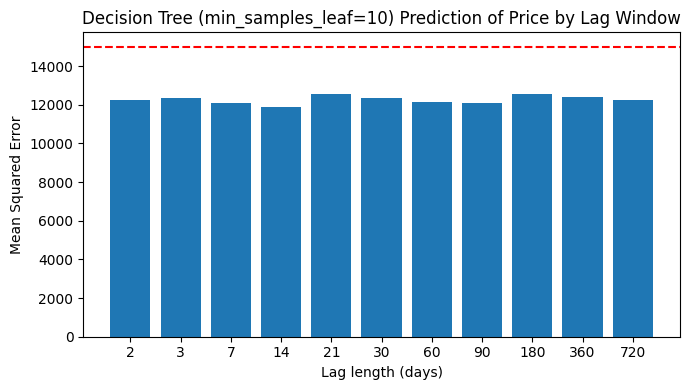

In [136]:
# Which family of lags is meaningless?

df = beef.join(lag_feat)

# keep only rows without missing lag features
df = df.dropna(subset=lag_feat.columns.tolist() + ["price", "Animal Type_num"])

lags = [2, 3, 7, 14, 21, 30, 60, 90, 180, 360, 720]
mse_scores = {}

cv = KFold(n_splits=5, shuffle=True, random_state=42)

for d in lags:
    # get the corresponding family of features
    feat_cols = [c for c in lag_feat.columns if f"__lag{d}_" in c]
    X = df[feat_cols + ["Animal Type_num"]]
    y = df["price"]

    model = DecisionTreeRegressor(min_samples_leaf=30, random_state=42)
    scores = cross_val_score(model, X, y, cv=cv, scoring="neg_mean_squared_error")
    mse_scores[d] = -scores.mean()

# --- baseline ---
baseline_model = DecisionTreeRegressor(random_state=42)
base_scores = cross_val_score(baseline_model, df[["Animal Type_num"]], df["price"], cv=cv, scoring="neg_mean_squared_error")
baseline_mse = -base_scores.mean()

# --- plot ---
plt.figure(figsize=(7,4))
plt.bar([str(k) for k in mse_scores.keys()], mse_scores.values())
plt.axhline(y=baseline_mse, color="red", linestyle="--", label="Baseline (mean)")
plt.xlabel("Lag length (days)")
plt.ylabel("Mean Squared Error")
plt.title("Decision Tree (min_samples_leaf=10) Prediction of Price by Lag Window")
plt.tight_layout()
plt.show()

# Generate Weather Window Table

In [12]:
weather_data = pd.read_csv("data/weather_preprocessed.csv")
beef = pd.read_csv("data/beef_preprocessed.csv")
beef['kill date'] = pd.to_datetime(beef['kill date'])
weather_data['Date(NZST)'] = pd.to_datetime(weather_data['Date(NZST)'])

C:\Users\kdo88\AppData\Local\Temp\ipykernel_16116\1776126063.py:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  weather_data = pd.read_csv("data/weather_preprocessed.csv")


In [13]:
weather_cols = [
    'MnDir(degT)', 'MnSpd(mps)', 'MnTemp(C)', 'MnRH(%)',
    'Rain(mm)', 'RadGlb(MJ/m2)', 'Average W/m2', 'Predicted BGT', 'THI', 'HLI', 'Grazing HLI2'
]
windows = {
    "0_4":   (0, 4),     # immediate stress before slaughter
    "5_10":   (5, 10),     # short-term past exposure
    "11_20":  (11, 20),    # medium-term
    "21_30": (21, 30),   # longer recent history
    "31_60": (31, 60),   # if age allows it
}

# Calculate thresholds from weather_data: 90th percentile (only 10% of measurements above)
threshold_cols = [
    "MnTemp(C)", "Predicted BGT", "MnRH(%)", "Rain(mm)",
    "RadGlb(MJ/m2)", "Average W/m2", "MnSpd(mps)",
    "THI", "HLI", "Grazing HLI2"
]
thresholds = {}
for col in threshold_cols:
    thresholds[col] = weather_data[col].quantile(0.90)

aggs = {
    'max': np.nanmax,
    'min': np.nanmin,
    'diff': lambda a: (np.nanmax(a) - np.nanmin(a)),
    'mean': np.nanmean,
    'std': np.nanstd
}

In [18]:
# result DF
window_feat = pd.DataFrame(index=beef.index)
w_dates = weather_data['Date(NZST)'].values

# convert age to days
age_days = (beef['Age'] * 30).astype(int)

# MAIN LOOP
for idx, (kdate, adays) in enumerate(zip(beef['kill date'].values, age_days.values)):

    feats = {}

    for wname, (d_min, d_max) in windows.items():

        # time bounds
        start = pd.Timestamp(kdate) - pd.Timedelta(days=d_max)
        end   = pd.Timestamp(kdate) - pd.Timedelta(days=d_min) - pd.Timedelta(seconds=1)

        mask = (w_dates >= start) & (w_dates <= end)
        sub = weather_data.loc[mask, weather_cols]

        # aggregations
        for col in weather_cols:
            arr = sub[col].to_numpy()

            # base aggregations
            if arr.size == 0 or np.all(np.isnan(arr)):
                for a in aggs:
                    feats[f"{col}__win{wname}_{a}"] = np.nan
            else:
                for a, fn in aggs.items():
                    try:
                        feats[f"{col}__win{wname}_{a}"] = fn(arr)
                    except Exception:
                        feats[f"{col}__win{wname}_{a}"] = np.nan

            # exposure counts for columns with thresholds
            if col in thresholds:
                thr = thresholds[col]
                if arr.size == 0 or np.all(np.isnan(arr)):
                    feats[f"{col}__win{wname}_above{round(thr, 2)}_count"] = np.nan
                else:
                    feats[f"{col}__win{wname}_above{round(thr, 2)}_count"] = np.sum(arr > thr)

    # assign
    # window_feat.loc[beef.index[idx], list(feats.keys())] = list(feats.values())
    window_feat.loc[idx, feats.keys()] = feats.values()

# drop zero-variance columns
window_feat = window_feat.loc[:, window_feat.var(numeric_only=True) > 0]

# save
window_feat.to_csv("data/beef_weather_windows.csv", index=False)
